In [1]:
import pandas as pd
import numpy as np

In [2]:
result_2SIC_p30 = pd.read_csv('/home/dxu39/scr4_jgray21/dxu39/projects/diffenergy/dfmdock_perturb_tr_likelihood/traj_likelihood/2SIC_p30_likelihood.csv')
result_2SIC_p90 = pd.read_csv('/home/dxu39/scr4_jgray21/dxu39/projects/diffenergy/dfmdock_perturb_tr_likelihood/traj_likelihood/2SIC_p90_likelihood.csv')
result_1IRA_p22 = pd.read_csv('/home/dxu39/scr4_jgray21/dxu39/projects/diffenergy/dfmdock_perturb_tr_likelihood/traj_likelihood/1IRA_p22_likelihood.csv')
result_1IRA_p36 = pd.read_csv('/home/dxu39/scr4_jgray21/dxu39/projects/diffenergy/dfmdock_perturb_tr_likelihood/traj_likelihood/1IRA_p36_likelihood.csv')

In [3]:
from matplotlib import pyplot as plt

In [4]:
from matplotlib import font_manager

font_dirs = ['/scratch4/jgray21/dxu39/miniforge3/envs/diffenergy/fonts']
font_files = font_manager.findSystemFonts(fontpaths=font_dirs)

for font_file in font_files:
    font_manager.fontManager.addfont(font_file)

# set font
plt.rcParams['font.family'] = 'Arial'
plt.rcParams["mathtext.fontset"] = 'cm'

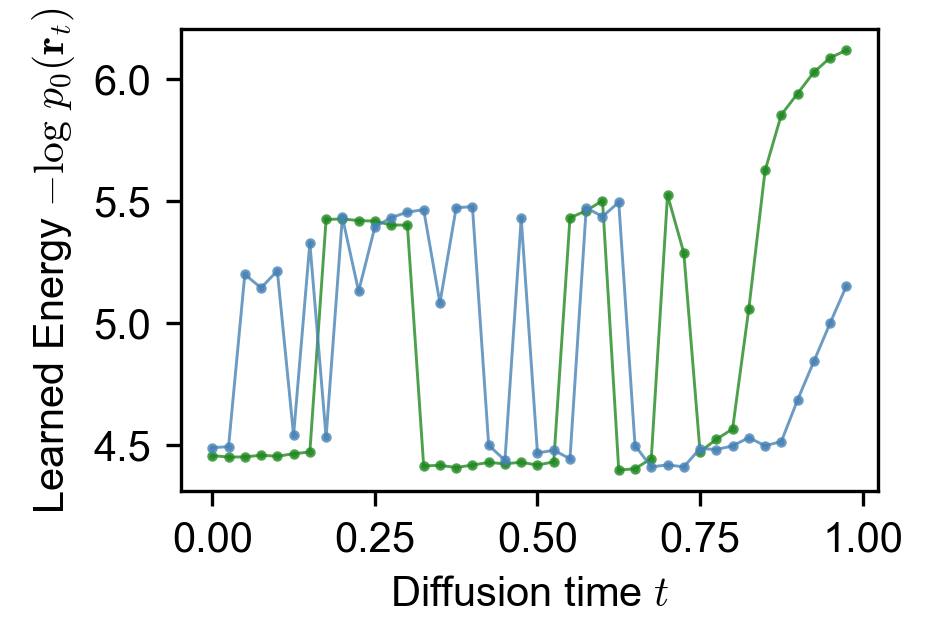

In [6]:
plt.plot(result_2SIC_p30.index.to_numpy()[::-1]/40, result_2SIC_p30.nll, marker='o', linestyle='-', c=(0.13,0.54,0.13,1.0), markersize=1.5, alpha=0.8, linewidth=0.7)
plt.plot(result_2SIC_p90.index.to_numpy()[::-1]/40, result_2SIC_p90.nll, marker='o', linestyle='-', c=(0.28,0.51,0.71,1.0), markersize=1.5, alpha=0.8, linewidth=0.7)
plt.xlabel('Diffusion time $t$')
plt.ylabel('Learned Energy $-\log\,p_{0}(\mathbf{r}_{t})$')
# plt.ylim(2.4, 6.4)
fig = plt.gcf()
fig.set_size_inches(3, 2)
fig.set_dpi(300)
plt.savefig('2SIC_single_traj_likelihood.png', dpi=300, bbox_inches='tight')

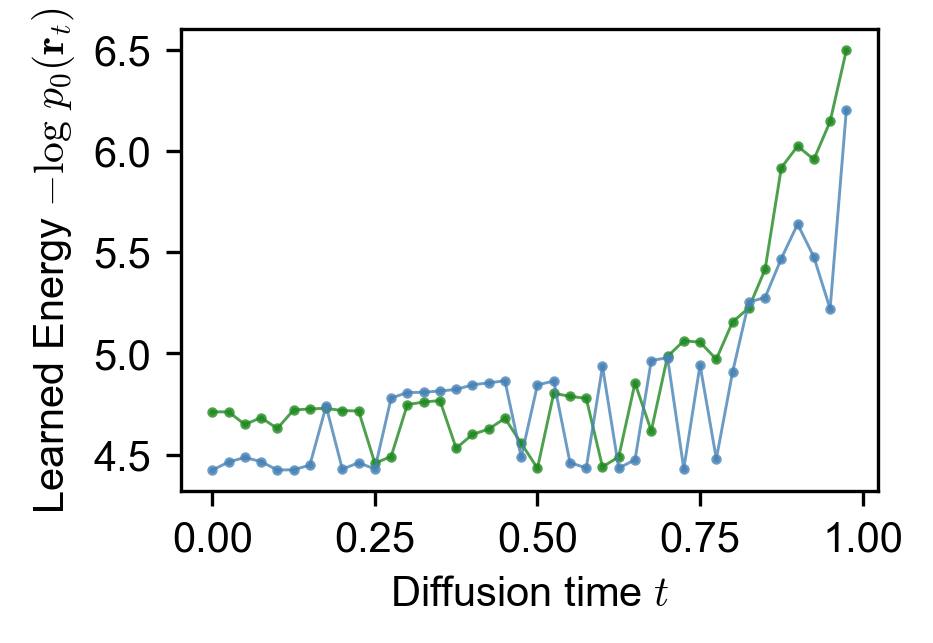

In [7]:
plt.plot(result_1IRA_p22.index.to_numpy()[::-1]/40, result_1IRA_p22.nll, marker='o', linestyle='-', c=(0.13,0.54,0.13,1.0), markersize=1.5, alpha=0.8, linewidth=0.7)
plt.plot(result_1IRA_p36.index.to_numpy()[::-1]/40, result_1IRA_p36.nll, marker='o', linestyle='-', c=(0.28,0.51,0.71,1.0), markersize=1.5, alpha=0.8, linewidth=0.7)
plt.xlabel('Diffusion time $t$')
plt.ylabel('Learned Energy $-\log\,p_{0}(\mathbf{r}_{t})$')
# plt.ylim(2.4, 6.4)
fig = plt.gcf()
fig.set_size_inches(3, 2)
fig.set_dpi(300)
plt.savefig('1IRA_single_traj_likelihood.png', dpi=300, bbox_inches='tight')

In [8]:
import pickle

In [9]:
with open('/home/dxu39/scr4_jgray21/dxu39/projects/diffenergy/dfmdock_perturb_tr_likelihood/traj_forces/traj_forces.pkl', 'rb') as f:
    traj_forces = pickle.load(f)

In [10]:
traj_force_dict = {item['id'].split('/')[-1].split('.')[0]: item for item in traj_forces}

In [11]:
np.linalg.norm(traj_force_dict['2SIC_p30']['score'], axis=1)

array([ 0.05003762,  0.05575769,  0.06411993,  0.07565591,  0.08984558,
        0.10526139,  0.1239167 ,  0.14440514,  0.16559692,  0.18830809,
        0.21717875,  0.2518789 ,  0.2934878 ,  0.3442848 ,  0.39845896,
        0.46111238,  0.52815586,  0.6072978 ,  0.7033837 ,  0.8175983 ,
        0.9459339 ,  1.0946532 ,  1.2661579 ,  1.4495616 ,  1.655812  ,
        1.8722193 ,  2.1149967 ,  2.3923151 ,  2.7056036 ,  3.0805798 ,
        3.519641  ,  4.0053487 ,  4.6259146 ,  5.3232865 ,  6.1478243 ,
        7.095358  ,  8.267866  ,  9.69955   , 11.3625765 , 13.066525  ],
      dtype=float32)

In [12]:
np.linalg.norm(traj_force_dict['2SIC_p90']['score'], axis=1)

array([ 0.0507055 ,  0.05643932,  0.06505388,  0.07662208,  0.08993647,
        0.10564165,  0.12398338,  0.14459364,  0.16430965,  0.18930897,
        0.21659239,  0.25189748,  0.29262388,  0.34390256,  0.39872208,
        0.4601644 ,  0.52820265,  0.6124155 ,  0.70460665,  0.8138327 ,
        0.94322455,  1.0955566 ,  1.2635767 ,  1.4525598 ,  1.6547132 ,
        1.8725202 ,  2.1178653 ,  2.392722  ,  2.70935   ,  3.0782611 ,
        3.4992027 ,  4.024721  ,  4.626727  ,  5.3240585 ,  6.1470056 ,
        7.094559  ,  8.265809  ,  9.699229  , 11.362286  , 13.077819  ],
      dtype=float32)

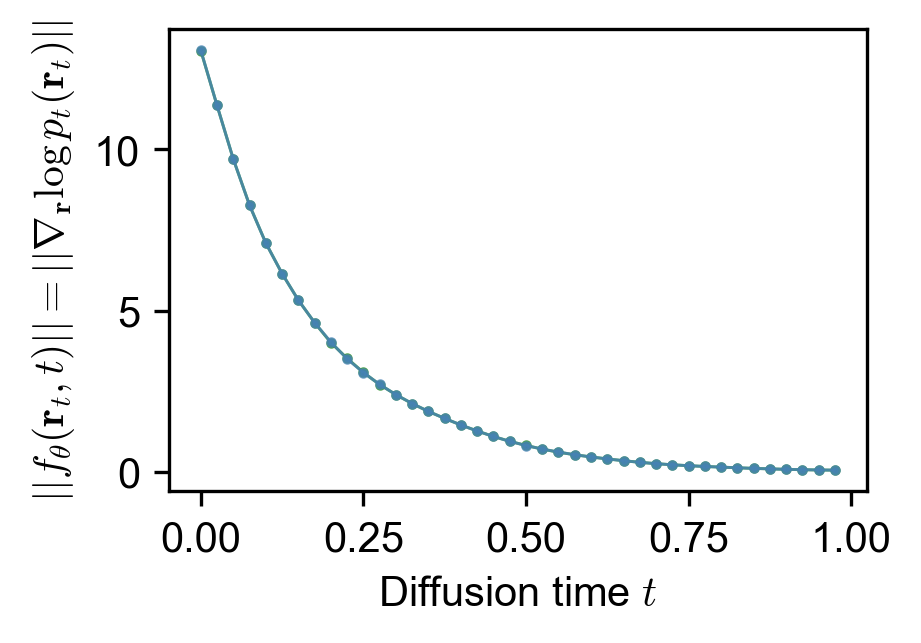

In [13]:
plt.plot(result_2SIC_p30.index.to_numpy()[::-1]/40, np.linalg.norm(traj_force_dict['2SIC_p30']['score'], axis=1), marker='o', linestyle='-', c=(0.13,0.54,0.13,1.0), markersize=1.5, alpha=0.8, linewidth=0.7)
plt.plot(result_2SIC_p90.index.to_numpy()[::-1]/40, np.linalg.norm(traj_force_dict['2SIC_p90']['score'], axis=1), marker='o', linestyle='-', c=(0.28,0.51,0.71,1.0), markersize=1.5, alpha=0.8, linewidth=0.7)
plt.xlabel('Diffusion time $t$')
plt.ylabel(r'$||f_{\theta} (\mathbf{r}_t,t)||=||\nabla_{\mathbf{r}} \log p_{t}(\mathbf{r}_{t})||$')
# plt.ylim(2.4, 6.4)
fig = plt.gcf()
fig.set_size_inches(3, 2)
fig.set_dpi(300)
plt.savefig('2SIC_single_traj_forces.png', dpi=300, bbox_inches='tight')

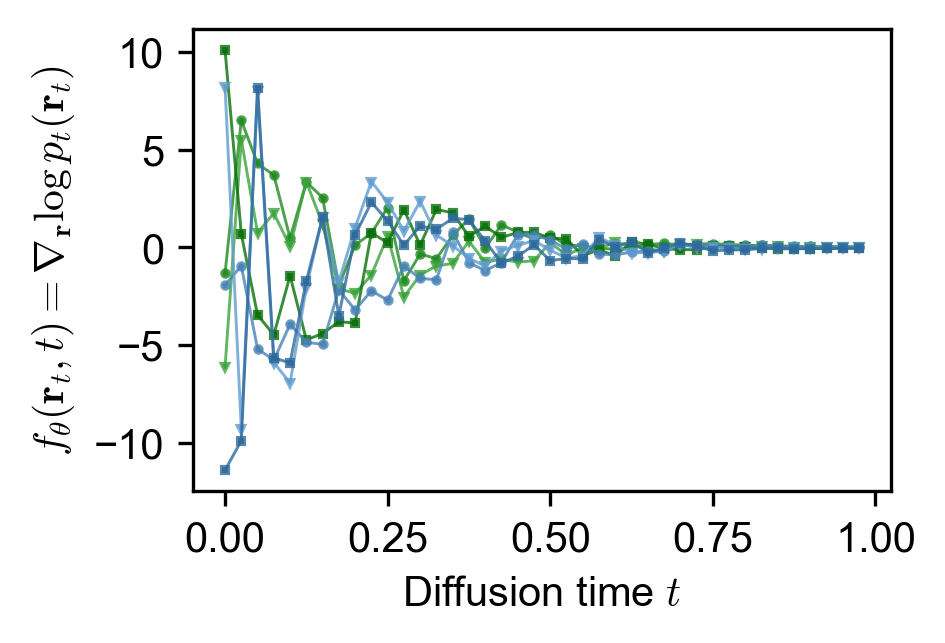

In [14]:
plt.plot(result_2SIC_p30.index.to_numpy()[::-1]/40, traj_force_dict['2SIC_p30']['score'][:,0], marker='o', linestyle='-', c=(0.13,0.54,0.13,1.0), markersize=1.5, alpha=0.8, linewidth=0.7)
plt.plot(result_2SIC_p90.index.to_numpy()[::-1]/40, traj_force_dict['2SIC_p90']['score'][:,0], marker='v', linestyle='-', c=(0.23,0.64,0.23,1.0), markersize=1.5, alpha=0.8, linewidth=0.7)
plt.plot(result_2SIC_p30.index.to_numpy()[::-1]/40, traj_force_dict['2SIC_p30']['score'][:,1], marker='s', linestyle='-', c=(0.03,0.44,0.03,1.0), markersize=1.5, alpha=0.8, linewidth=0.7)
plt.plot(result_2SIC_p90.index.to_numpy()[::-1]/40, traj_force_dict['2SIC_p90']['score'][:,1], marker='o', linestyle='-', c=(0.28,0.51,0.71,1.0), markersize=1.5, alpha=0.8, linewidth=0.7)
plt.plot(result_2SIC_p30.index.to_numpy()[::-1]/40, traj_force_dict['2SIC_p30']['score'][:,2], marker='v', linestyle='-', c=(0.38,0.61,0.81,1.0), markersize=1.5, alpha=0.8, linewidth=0.7)
plt.plot(result_2SIC_p90.index.to_numpy()[::-1]/40, traj_force_dict['2SIC_p90']['score'][:,2], marker='s', linestyle='-', c=(0.18,0.41,0.61,1.0), markersize=1.5, alpha=0.8, linewidth=0.7)
plt.xlabel('Diffusion time $t$')
plt.ylabel(r'$f_{\theta} (\mathbf{r}_t,t)=\nabla_{\mathbf{r}} \log p_{t}(\mathbf{r}_{t})$')
# plt.ylim(2.4, 6.4)
fig = plt.gcf()
fig.set_size_inches(3, 2)
fig.set_dpi(300)
plt.savefig('2SIC_single_traj_forces_indi.png', dpi=300, bbox_inches='tight')

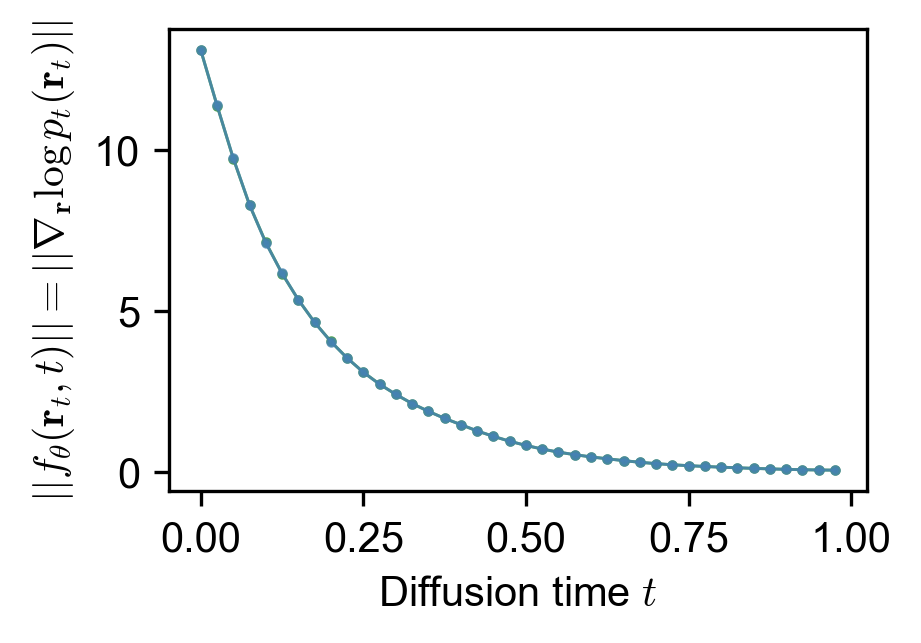

In [15]:
plt.plot(result_1IRA_p22.index.to_numpy()[::-1]/40, np.linalg.norm(traj_force_dict['1IRA_p22']['score'], axis=1), marker='o', linestyle='-', c=(0.13,0.54,0.13,1.0), markersize=1.5, alpha=0.8, linewidth=0.7)
plt.plot(result_1IRA_p36.index.to_numpy()[::-1]/40, np.linalg.norm(traj_force_dict['1IRA_p36']['score'], axis=1), marker='o', linestyle='-', c=(0.28,0.51,0.71,1.0), markersize=1.5, alpha=0.8, linewidth=0.7)
plt.xlabel('Diffusion time $t$')
plt.ylabel(r'$||f_{\theta} (\mathbf{r}_t,t)||=||\nabla_{\mathbf{r}} \log p_{t}(\mathbf{r}_{t})||$')
# plt.ylim(2.4, 6.4)
fig = plt.gcf()
fig.set_size_inches(3, 2)
fig.set_dpi(300)
plt.savefig('1IRA_single_traj_forces.png', dpi=300, bbox_inches='tight')

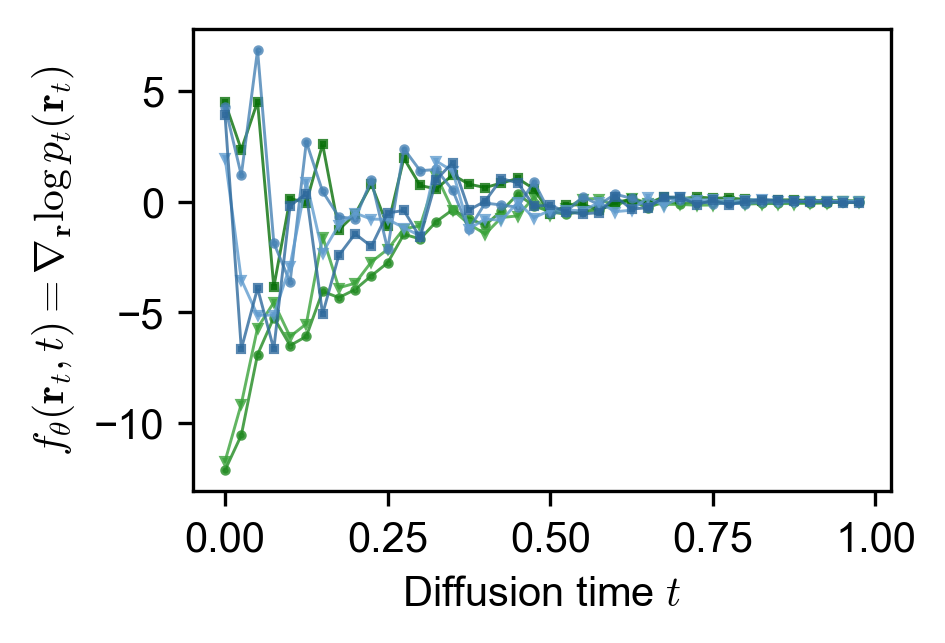

In [16]:
plt.plot(result_1IRA_p22.index.to_numpy()[::-1]/40, traj_force_dict['1IRA_p22']['score'][:,0], marker='o', linestyle='-', c=(0.13,0.54,0.13,1.0), markersize=1.5, alpha=0.8, linewidth=0.7)
plt.plot(result_1IRA_p36.index.to_numpy()[::-1]/40, traj_force_dict['1IRA_p36']['score'][:,0], marker='v', linestyle='-', c=(0.23,0.64,0.23,1.0), markersize=1.5, alpha=0.8, linewidth=0.7)
plt.plot(result_1IRA_p22.index.to_numpy()[::-1]/40, traj_force_dict['1IRA_p22']['score'][:,1], marker='s', linestyle='-', c=(0.03,0.44,0.03,1.0), markersize=1.5, alpha=0.8, linewidth=0.7)
plt.plot(result_1IRA_p36.index.to_numpy()[::-1]/40, traj_force_dict['1IRA_p36']['score'][:,1], marker='o', linestyle='-', c=(0.28,0.51,0.71,1.0), markersize=1.5, alpha=0.8, linewidth=0.7)
plt.plot(result_1IRA_p22.index.to_numpy()[::-1]/40, traj_force_dict['1IRA_p22']['score'][:,2], marker='v', linestyle='-', c=(0.38,0.61,0.81,1.0), markersize=1.5, alpha=0.8, linewidth=0.7)
plt.plot(result_1IRA_p36.index.to_numpy()[::-1]/40, traj_force_dict['1IRA_p36']['score'][:,2], marker='s', linestyle='-', c=(0.18,0.41,0.61,1.0), markersize=1.5, alpha=0.8, linewidth=0.7)
plt.xlabel('Diffusion time $t$')
plt.ylabel(r'$f_{\theta} (\mathbf{r}_t,t)=\nabla_{\mathbf{r}} \log p_{t}(\mathbf{r}_{t})$')
# plt.ylim(2.4, 6.4)
fig = plt.gcf()
fig.set_size_inches(3, 2)
fig.set_dpi(300)
plt.savefig('1IRA_single_traj_forces_indi.png', dpi=300, bbox_inches='tight')

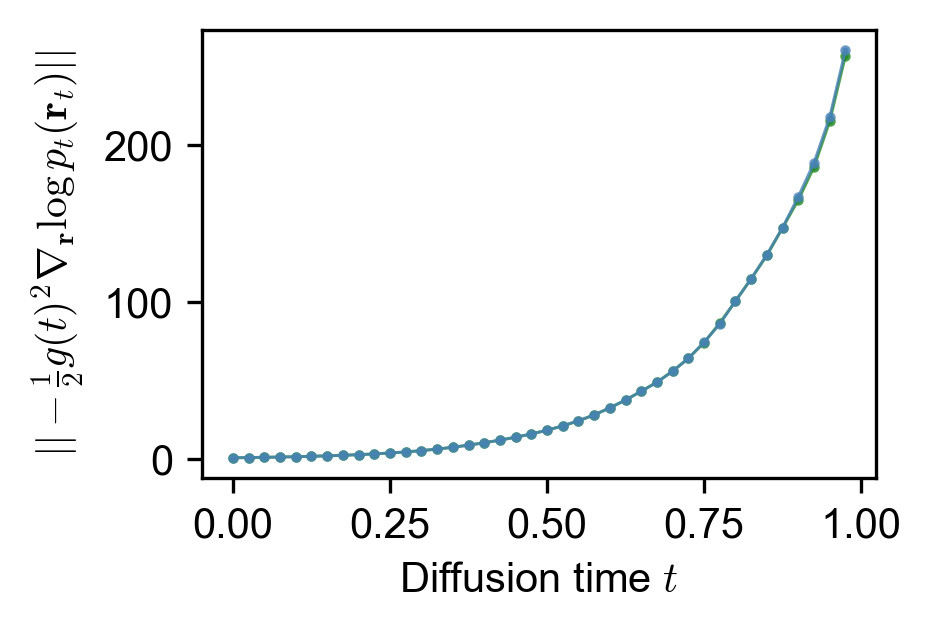

In [17]:
plt.plot(result_2SIC_p30.index.to_numpy()[::-1]/40, np.linalg.norm(traj_force_dict['2SIC_p30']['sample_grad'], axis=1), marker='o', linestyle='-', c=(0.13,0.54,0.13,1.0), markersize=1.5, alpha=0.8, linewidth=0.7)
plt.plot(result_2SIC_p90.index.to_numpy()[::-1]/40, np.linalg.norm(traj_force_dict['2SIC_p90']['sample_grad'], axis=1), marker='o', linestyle='-', c=(0.28,0.51,0.71,1.0), markersize=1.5, alpha=0.8, linewidth=0.7)
plt.xlabel('Diffusion time $t$')
plt.ylabel(r'$||-\frac{1}{2}g(t)^2 \nabla_{\mathbf{r}} \log p_{t}(\mathbf{r}_{t})||$')
# plt.ylim(2.4, 6.4)
fig = plt.gcf()
fig.set_size_inches(3.2, 2.2)
fig.set_dpi(300)
plt.tight_layout()
plt.savefig('2SIC_single_traj_scaled_force.png', dpi=300, bbox_inches='tight')

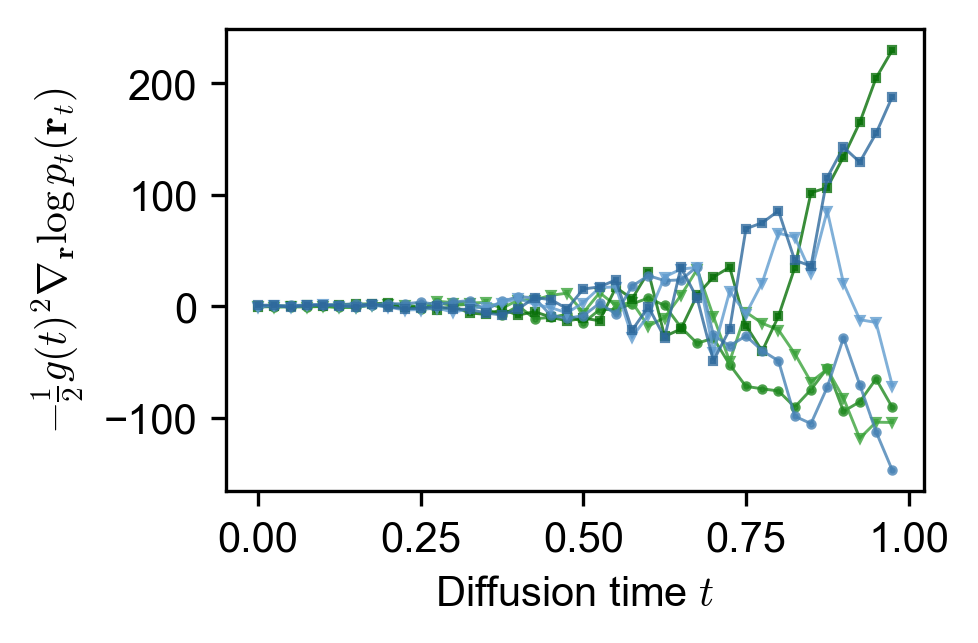

In [18]:
plt.plot(result_2SIC_p30.index.to_numpy()[::-1]/40, traj_force_dict['2SIC_p30']['sample_grad'][:,0], marker='o', linestyle='-', c=(0.13,0.54,0.13,1.0), markersize=1.5, alpha=0.8, linewidth=0.7)
plt.plot(result_2SIC_p90.index.to_numpy()[::-1]/40, traj_force_dict['2SIC_p90']['sample_grad'][:,0], marker='v', linestyle='-', c=(0.23,0.64,0.23,1.0), markersize=1.5, alpha=0.8, linewidth=0.7)
plt.plot(result_2SIC_p30.index.to_numpy()[::-1]/40, traj_force_dict['2SIC_p30']['sample_grad'][:,1], marker='s', linestyle='-', c=(0.03,0.44,0.03,1.0), markersize=1.5, alpha=0.8, linewidth=0.7)
plt.plot(result_2SIC_p90.index.to_numpy()[::-1]/40, traj_force_dict['2SIC_p90']['sample_grad'][:,1], marker='o', linestyle='-', c=(0.28,0.51,0.71,1.0), markersize=1.5, alpha=0.8, linewidth=0.7)
plt.plot(result_2SIC_p30.index.to_numpy()[::-1]/40, traj_force_dict['2SIC_p30']['sample_grad'][:,2], marker='v', linestyle='-', c=(0.38,0.61,0.81,1.0), markersize=1.5, alpha=0.8, linewidth=0.7)
plt.plot(result_2SIC_p90.index.to_numpy()[::-1]/40, traj_force_dict['2SIC_p90']['sample_grad'][:,2], marker='s', linestyle='-', c=(0.18,0.41,0.61,1.0), markersize=1.5, alpha=0.8, linewidth=0.7)
plt.xlabel('Diffusion time $t$')
plt.ylabel(r'$-\frac{1}{2}g(t)^2 \nabla_{\mathbf{r}} \log p_{t}(\mathbf{r}_{t})$')
# plt.ylim(2.4, 6.4)
fig = plt.gcf()
fig.set_size_inches(3, 2)
fig.set_dpi(300)
plt.savefig('2SIC_single_traj_scaled_forces_indi.png', dpi=300, bbox_inches='tight')

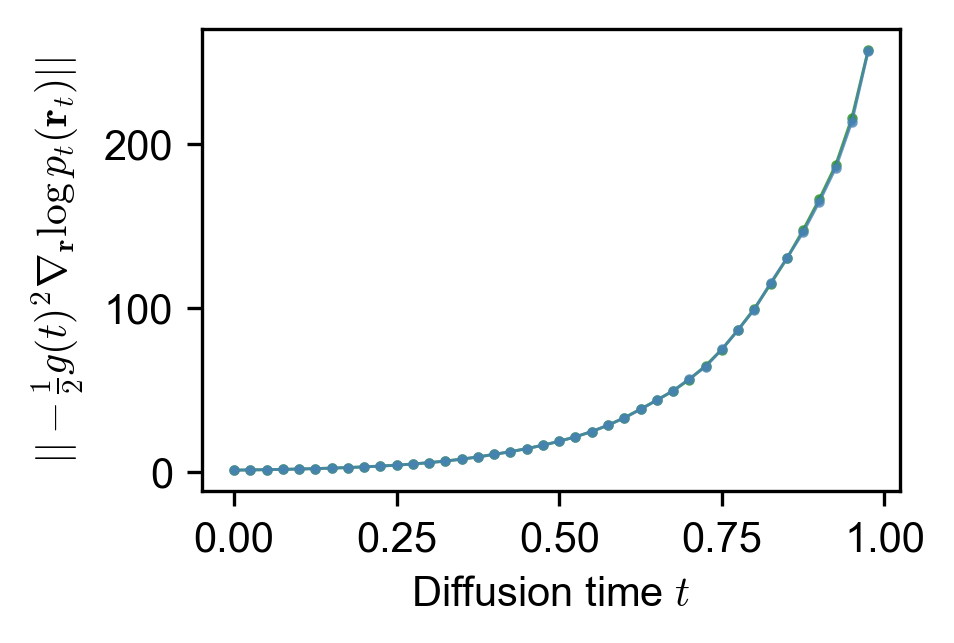

In [19]:
plt.plot(result_1IRA_p22.index.to_numpy()[::-1]/40, np.linalg.norm(traj_force_dict['1IRA_p22']['sample_grad'], axis=1), marker='o', linestyle='-', c=(0.13,0.54,0.13,1.0), markersize=1.5, alpha=0.8, linewidth=0.7)
plt.plot(result_1IRA_p36.index.to_numpy()[::-1]/40, np.linalg.norm(traj_force_dict['1IRA_p36']['sample_grad'], axis=1), marker='o', linestyle='-', c=(0.28,0.51,0.71,1.0), markersize=1.5, alpha=0.8, linewidth=0.7)
plt.xlabel('Diffusion time $t$')
plt.ylabel(r'$||-\frac{1}{2}g(t)^2 \nabla_{\mathbf{r}} \log p_{t}(\mathbf{r}_{t})||$')
# plt.ylim(2.4, 6.4)
fig = plt.gcf()
fig.set_size_inches(3, 2)
fig.set_dpi(300)
plt.savefig('1IRA_single_traj_scaled_force.png', dpi=300, bbox_inches='tight')

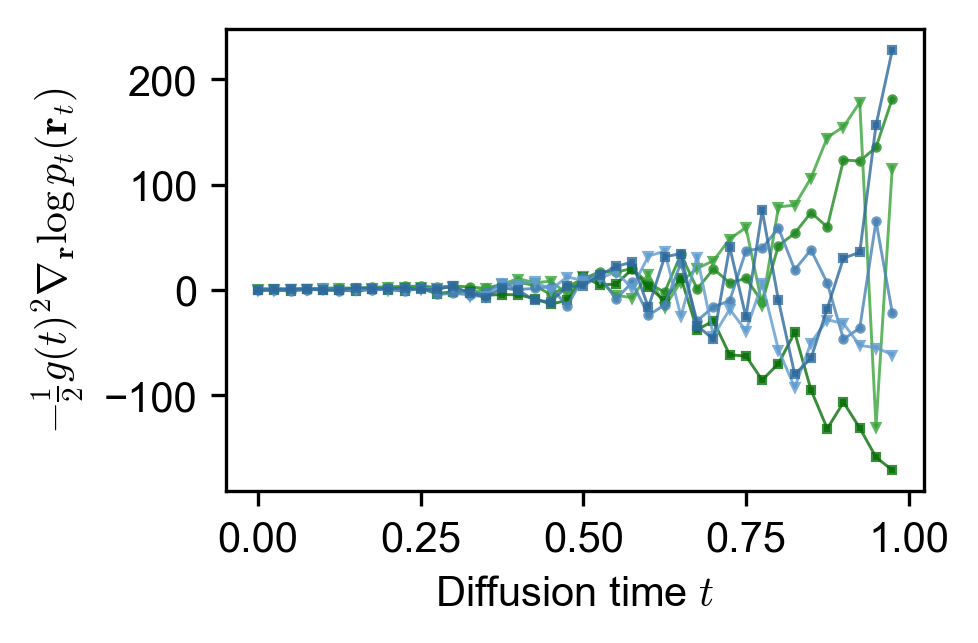

In [20]:
plt.plot(result_1IRA_p22.index.to_numpy()[::-1]/40, traj_force_dict['1IRA_p22']['sample_grad'][:,0], marker='o', linestyle='-', c=(0.13,0.54,0.13,1.0), markersize=1.5, alpha=0.8, linewidth=0.7)
plt.plot(result_1IRA_p36.index.to_numpy()[::-1]/40, traj_force_dict['1IRA_p36']['sample_grad'][:,0], marker='v', linestyle='-', c=(0.23,0.64,0.23,1.0), markersize=1.5, alpha=0.8, linewidth=0.7)
plt.plot(result_1IRA_p22.index.to_numpy()[::-1]/40, traj_force_dict['1IRA_p22']['sample_grad'][:,1], marker='s', linestyle='-', c=(0.03,0.44,0.03,1.0), markersize=1.5, alpha=0.8, linewidth=0.7)
plt.plot(result_1IRA_p36.index.to_numpy()[::-1]/40, traj_force_dict['1IRA_p36']['sample_grad'][:,1], marker='o', linestyle='-', c=(0.28,0.51,0.71,1.0), markersize=1.5, alpha=0.8, linewidth=0.7)
plt.plot(result_1IRA_p22.index.to_numpy()[::-1]/40, traj_force_dict['1IRA_p22']['sample_grad'][:,2], marker='v', linestyle='-', c=(0.38,0.61,0.81,1.0), markersize=1.5, alpha=0.8, linewidth=0.7)
plt.plot(result_1IRA_p36.index.to_numpy()[::-1]/40, traj_force_dict['1IRA_p36']['sample_grad'][:,2], marker='s', linestyle='-', c=(0.18,0.41,0.61,1.0), markersize=1.5, alpha=0.8, linewidth=0.7)
plt.xlabel('Diffusion time $t$')
plt.ylabel(r'$-\frac{1}{2}g(t)^2 \nabla_{\mathbf{r}} \log p_{t}(\mathbf{r}_{t})$')
# plt.ylim(2.4, 6.4)
fig = plt.gcf()
fig.set_size_inches(3, 2)
fig.set_dpi(300)
plt.savefig('1IRA_single_traj_scaled_forces_indi.png', dpi=300, bbox_inches='tight')

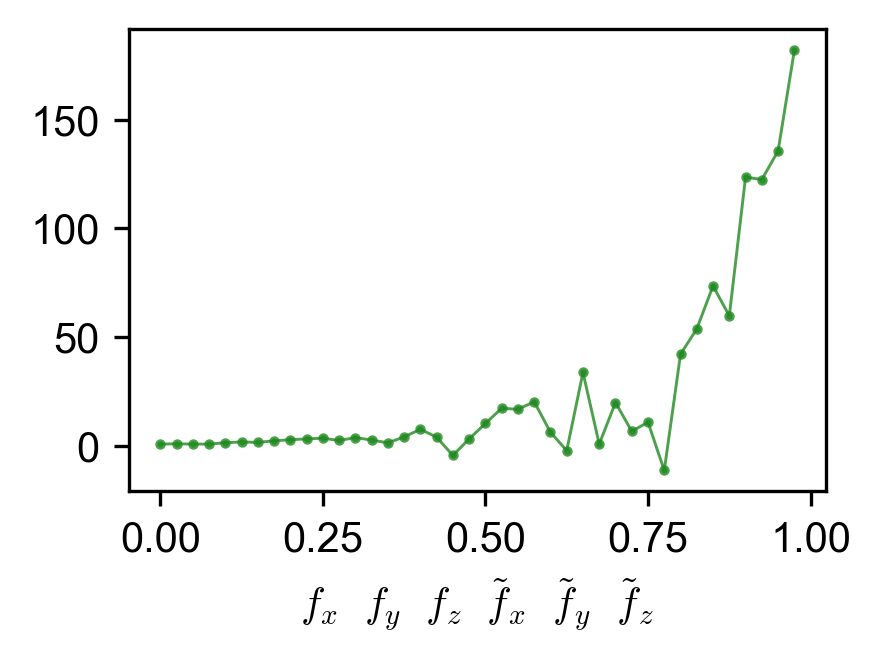

In [21]:
plt.plot(result_1IRA_p22.index.to_numpy()[::-1]/40, traj_force_dict['1IRA_p22']['sample_grad'][:,0], marker='o', linestyle='-', c=(0.13,0.54,0.13,1.0), markersize=1.5, alpha=0.8, linewidth=0.7)
# plt.xlabel('Diffusion time $t$')
plt.xlabel(r'$f_{x}\ \ f_{y}\ \ f_{z}\ \ \tilde{f}_{x}\ \ \tilde{f}_{y}\ \ \tilde{f}_{z}$')
# plt.ylim(2.4, 6.4)
fig = plt.gcf()
fig.set_size_inches(3, 2)
fig.set_dpi(300)
plt.savefig('labels.png', dpi=300, bbox_inches='tight')